<a href="https://colab.research.google.com/github/sindhukanakapudi/Image-Based-Fruit-Quality-Classification-Sysytem/blob/main/Fruit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import  os
dataset_path="/content/drive/MyDrive/Fruit Dataset/Augmented Image"
folders=os.listdir(dataset_path)
print(folders)

['FreshOrange', 'FreshGuava', 'RottenStrawberry', 'FreshApple', 'FreshStrawberry', 'RottenApple', 'FreshGrape', 'RottenGuava', 'RottenOrange', 'RottenGrape', 'FreshJujube', 'RottenJujube', 'FreshBanana', 'RottenPomegranate', 'FreshPomegranate', 'RottenBanana']


In [ ]:
import os
for folder in folders:
  path=os.path.join(dataset_path,folder)
  count=len(os.listdir(path))
  print(folder,":",count)


FreshOrange : 796
FreshGuava : 797
RottenStrawberry : 737
FreshApple : 734
FreshStrawberry : 737
RottenApple : 738
FreshGrape : 800
RottenGuava : 797
RottenOrange : 796
RottenGrape : 746
FreshJujube : 793
RottenJujube : 793
FreshBanana : 740
RottenPomegranate : 798
FreshPomegranate : 818
RottenBanana : 736


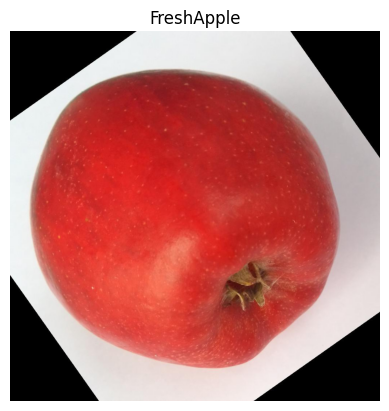

In [ ]:
import matplotlib.pyplot as plt
import os
folder="FreshApple"
path=os.path.join(dataset_path,folder)
image=os.listdir(path)[0]
image_path=os.path.join(path,image)
img=plt.imread(image_path)
plt.imshow(img)
plt.title(folder)
plt.axis("off")
plt.show()

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path="/content/drive/MyDrive/Fruit Dataset/Augmented Image"

In [ ]:
folders=os.listdir(dataset_path)
print(folders)

['FreshOrange', 'FreshGuava', 'RottenStrawberry', 'FreshApple', 'FreshStrawberry', 'RottenApple', 'FreshGrape', 'RottenGuava', 'RottenOrange', 'RottenGrape', 'FreshJujube', 'RottenJujube', 'FreshBanana', 'RottenPomegranate', 'FreshPomegranate', 'RottenBanana']


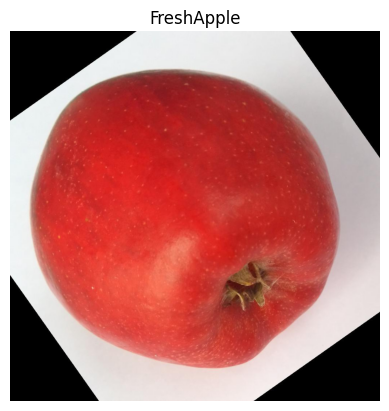

In [ ]:
folder="FreshApple"
path=os.path.join(dataset_path,folder)
image=os.listdir(path)[0]
image_path=os.path.join(path,image)
img=plt.imread(image_path)
plt.imshow(img)
plt.title(folder)
plt.axis("off")
plt.show()

In [ ]:
train_datagen=ImageDataGenerator(
      rescale=1./255,
      validation_split=0.2
      )

In [ ]:
train_data=train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

Found 9891 images belonging to 16 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
model=Sequential([
    Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation="relu"),
    Dense(train_data.num_classes,
          activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,909,456 (91.21 MB)

 Trainable params: 23,909,456 (91.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
validation_data=train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 2465 images belonging to 16 classes.


In [13]:
history =model.fit(
    train_data,
    validation_data=validation_data,
    epochs=5
)

Epoch 1/5
103/310 ━━━━━━━━━━━━━━━━━━━━ 37:58 11s/step - accuracy: 0.1219 - loss: 4.7987

KeyboardInterrupt: 

In [15]:
model.save("fruit_quality_model.keras.h5",include_optimizer=False)

In [ ]:
loss,accuracy=model.evaluate(validation_data)
print("Loss:",loss)
print("Accuracy:",accuracy)

25/78 ━━━━━━━━━━━━━━━━━━━━ 18:48 21s/step - accuracy: 0.0678 - loss: 2.7749

In [ ]:
from google.colab import files
uploaded=files.upload()

In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
img_path=list(uploaded.keys())[0]
img=image.load_img(img_path,target_size=(224,224))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import numpy as np
img_array =image.img_to_array(img)
img_array=img_array/255.0
img_array=np.expand_dims(img_array,axis=0)

In [ ]:
prediction=model.predict(img_array)
predict_class=np.argmax(prediction)
confidence=np.max(prediction)*100
print("predicted class index",predict_class)
print("confidence: {:.2f}%".format(confidence))

In [ ]:
print(train_data.class_indices)

{'FreshApple': 0, 'FreshBanana': 1, 'FreshGrape': 2, 'FreshGuava': 3, 'FreshJujube': 4, 'FreshOrange': 5, 'FreshPomegranate': 6, 'FreshStrawberry': 7, 'RottenApple': 8, 'RottenBanana': 9, 'RottenGrape': 10, 'RottenGuava': 11, 'RottenJujube': 12, 'RottenOrange': 13, 'RottenPomegranate': 14, 'RottenStrawberry': 15}


In [ ]:
class_names=list(train_data.class_indices.keys())
predicted_label=class_names[predict_class]
print("predicted fruit:",predicted_label)
print("confidence: {:.2f}%".format(confidence))

In [ ]:
from google.colab import files
files.download("fruit_quality_model.keras")

In [ ]:
from  google.colab import drive
drive.mount('/content/drive')

In [ ]:
from tensorflow.keras.models import load_model
model=load_model("/content/drive/MyDrive/fruit_quality_model.keras")
print("model loaded successfully")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
dataset_path="/content/drive/MyDrive/Fruit Dataset/Augmented Image"
train_datagen=ImageDataGenerator(
      rescale=1./255)

train_data=train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

In [ ]:
print(train_data.class_indices)

{'FreshApple': 0, 'FreshBanana': 1, 'FreshGrape': 2, 'FreshGuava': 3, 'FreshJujube': 4, 'FreshOrange': 5, 'FreshPomegranate': 6, 'FreshStrawberry': 7, 'RottenApple': 8, 'RottenBanana': 9, 'RottenGrape': 10, 'RottenGuava': 11, 'RottenJujube': 12, 'RottenOrange': 13, 'RottenPomegranate': 14, 'RottenStrawberry': 15}


In [ ]:
label= predicted_label.replace("Fresh", "Fresh ").replace("Rotten", "Rotten ")

print("========== Prediction Result ==========")
print("Fruit:", label)
print("Confidence: {:.2f}%".format(confidence))

if "Fresh" in label:
    print("Recommendation: Suitable for sale and consumption.")
else:
    print("Recommendation: Remove from stock. Not suitable for consumption.")

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0
